# Approche Machine Learning (HOG, SVM et K-Means)

In [ ]:
# Importation des bibliothèques nécessaires
import sys
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2

# Pour la détection
from skimage.feature import hog
from skimage import data, exposure
from sklearn.svm import LinearSVC
import random

# Pour la classification avec KMeans
from sklearn.cluster import KMeans

# Pour l'évaluation des performances du modèle de classification
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Ajoute explicitement le dossier src au chemin Python
sys.path.append('../src')

# Importation des fonctions depuis le module local src/utils.py
from utils import (
    init_lists_0, 
    calculer_metriques_classif, 
    afficher_metriques_classif,
    calculate_iou,
    fusionner_boites_englobantes,
    garder_plus_grande_boite,
    clean_noise,
    get_clusters
)

# Assurer la reproduction des résultats
random.seed(42)

### Initialisation des listes

Pour nous simplifier la lecture des fichiers (images et labels), on crée une liste qui référence tous les chemins relatifs aux images selon l'arborescence et une autre liste qui prendra les contenus des textes associés aux images. Ils auront alors les mêmes indices.

In [ ]:
# Initialisation des listes
im_add, labels = init_lists_0()

# Vérification : On doit avoir 168 (sauf si on ne compte pas le fichier en .gif qui est illisible donc 167) adresses d'images et listes de labels 
print(f"On a {len(im_add)} adresses d'images et {len(labels)} listes de labels.")

# On créera une liste de cardinaux à partir des véritables étiquettes (GT_card) pour faciliter la lecture des résultats
dict_card_fr = {0: "EST", 1: "NORD", 2: "SUD", 3: "OUEST"} 
GT_card = [dict_card_fr[labels[k][0]] for k in range(len(im_add))]

On a 167 adresses d'images et 167 listes de labels.


### Détection : Pas à pas

Pour la détection de bouée pour l'approche "Machine Learning", nous décidons de nous inspirer du Tutoriel 10 du module "Advanced Image Analysis" du bloc "Image Science (1)" en utilisant l'extraction de caractéristiques de HOG et SVM.

On suivra la même approche, c'est-à-dire :
1. Collecter et préparer l'ensemble de données
2. Extraire les caractéristiques HOG
3. Entraîner le classificateur SVM
4. Évaluer le classificateur

In [3]:
# Choix d'une image aléatoire ou pas
ALEATOIRE = False
if ALEATOIRE :
    c = random.randint(0, len(im_add) - 1)
else : c = 6

adresse_img, liste = im_add[c], labels[c]
print(f"On a choisi l'image numéro                  : {c}")

# Liste des coordonnées de type [xmin, ymin, xmax, ymax]
print(f"La bounding box de la bouée est situé en    : [xmin, ymin, xmax, ymax] = {liste[1:]}")
print(f"Le numéro du cardinal est                   : {liste[0]} (correspond à {dict_card_fr[liste[0]]})")

On a choisi l'image numéro                  : 6
La bounding box de la bouée est situé en    : [xmin, ymin, xmax, ymax] = [117, 47, 617, 909]
Le numéro du cardinal est                   : 0 (correspond à EST)


HOG feature vector length: 429768


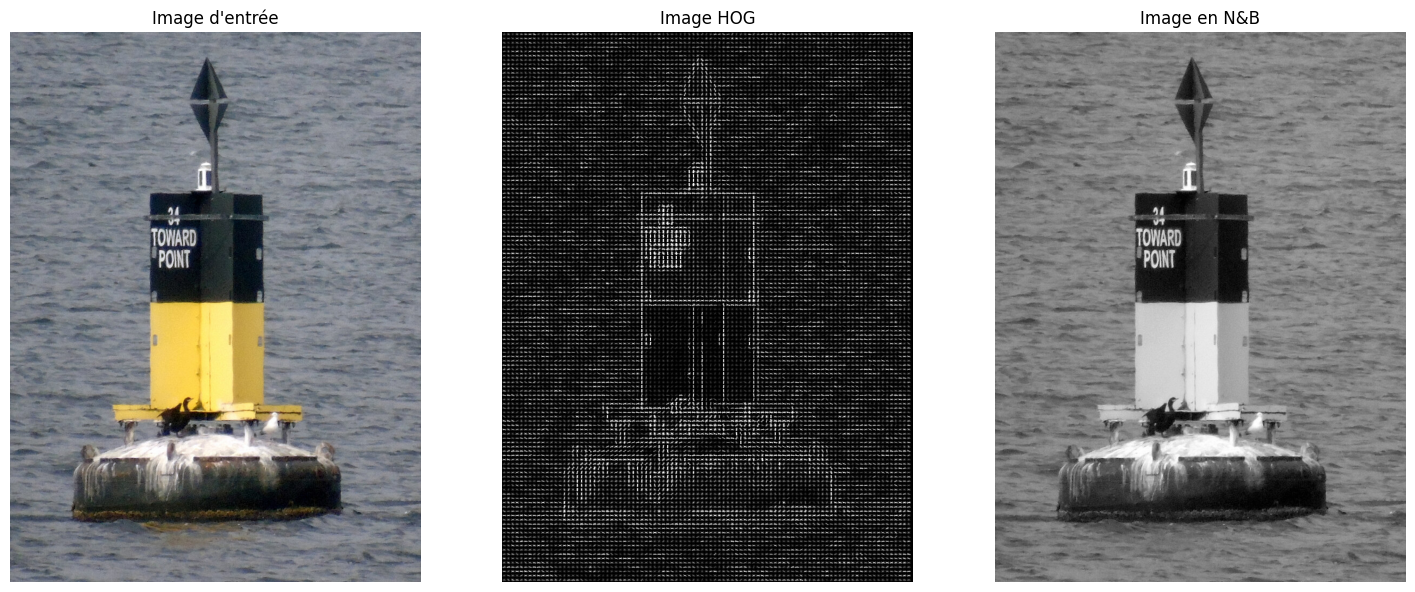

In [4]:
# On ouvre l'image pour la détection de HOG avec openCV
image = cv2.imread(adresse_img)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Application du HOG sur l'image originale
fd, hog_image = hog(image, orientations = 9, pixels_per_cell = (8, 8), cells_per_block = (2, 2), visualize = True, channel_axis=-1)
print("HOG feature vector length:", len(fd))

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range = (0, 10))

plt.figure(figsize = (18, 8))

plt.subplot(131); plt.imshow(image_rgb, cmap = "gray"); plt.axis("off"); plt.title("Image d'entrée")
plt.subplot(132); plt.imshow(hog_image_rescaled, cmap = "gray"); plt.axis("off"); plt.title("Image HOG")
plt.subplot(133); plt.imshow(img_gray, cmap = "gray"); plt.axis("off"); plt.title("Image en N&B")

plt.show();

In [5]:
# On définit les paramètres pour HOG
winSize = (64, 128) # Taille de la fenêtre d'entrée pour HOG
blockSize = (2, 2)
cellSize = (8, 8)
nbins = 9

# Fonction pour extraire les caractéristiques HOG d'une image
def extract_hog_features(img):
    """Extrait le vecteur de caractéristiques HOG d'une image."""
    # Redimensionnement à la taille de la fenêtre
    img_resized = cv2.resize(img, winSize)
    
    # Conversion en niveaux de gris
    if len(img_resized.shape) == 3:
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_resized
        
    # Calcul du HOG
    features = hog(img_gray, orientations=nbins, pixels_per_cell=cellSize,
                   cells_per_block=blockSize, block_norm='L2-Hys', 
                   visualize=False, transform_sqrt=True)
    return features

In [ ]:
# On crée des échantillons positifs et négatif à partir des annotations pour entraîner le SVM
print("Début de l'entraînement du modèle SVM")

X = [] # Contiendra les features HOG
y = [] # Contiendra les labels (1 = Bouée, 0 = Fond)
positive = []
negative = []

# On va choisir la moitié des images comme images d'entraînement
num_samples = len(im_add)//2

# Chargement des VRAIES images Positives (Bouées)
for indice in range(num_samples):
    img = cv2.imread(im_add[indice])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label = labels[indice]
    img = img[label[2]:label[4], label[1]:label[3]] # On recadre pour ne garder que la bouée
    positive.append(img)
    X.append(extract_hog_features(img))
    y.append(1)

# Chargement des VRAIES images Négatives (Fond marin)
for indice in range(num_samples):
    img = cv2.imread(im_add[indice])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# On va prendre la région en haut à gauche de l'image (hors de la bouée) pour les échantillons négatifs
    xmin, ymin, xmax, ymax = 0, 0, winSize[0], winSize[1] # Coin supérieur gauche
    img = img[ymin:ymax, xmin:xmax] # On recadre pour ne garder que la bouée
    negative.append(img)
    X.append(extract_hog_features(img))
    y.append(0)

# Entraînement du classifieur SVM
svm_model = LinearSVC(random_state=42, dual=False, max_iter=2000)
svm_model.fit(X, y)
print("Fin de l'entraînement du modèle SVM")

Début de l'entraînement du modèle SVM
Fin de l'entraînement du modèle SVM


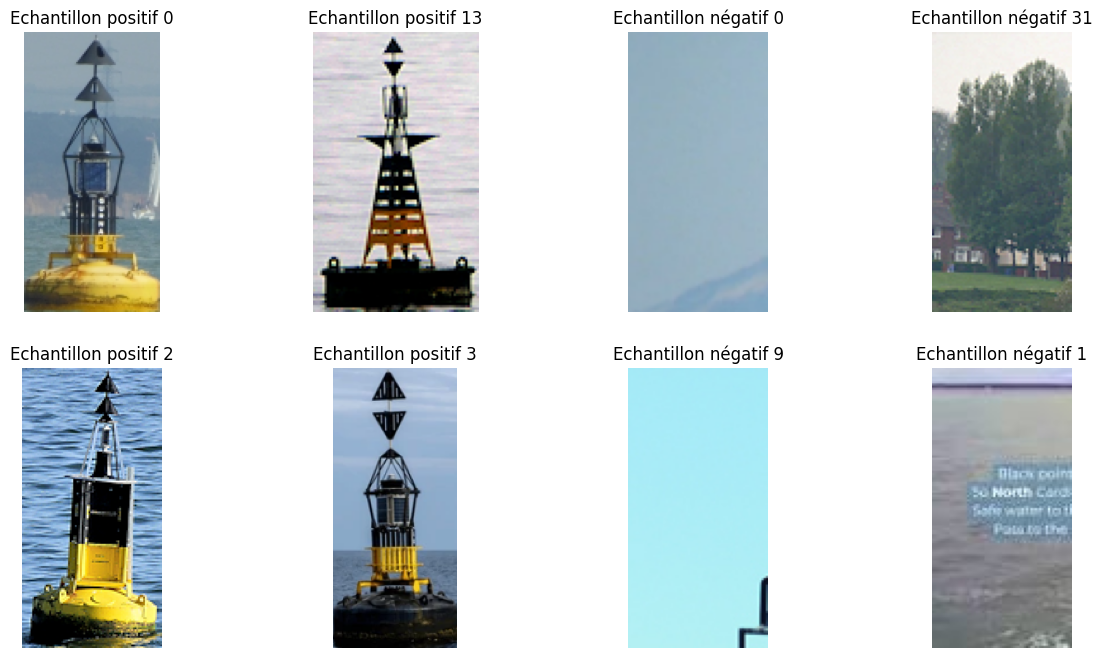

Echantillons positifs : 83
Echantillons négatifs : 83


In [ ]:
# On affiche quelques échantillons positifs et négatifs pour vérifier à quoi ils ressemblent
indices_pos = random.sample(range(len(positive)), min(32, len(positive))) 

plt.figure(figsize=(15, 8))
plt.subplot(241); plt.imshow(positive[indices_pos[0]]); plt.title("Echantillon positif 0"); plt.axis('off')
plt.subplot(242); plt.imshow(positive[indices_pos[1]]); plt.title("Echantillon positif 13"); plt.axis('off')
plt.subplot(243); plt.imshow(negative[indices_pos[2]]); plt.title("Echantillon négatif 0"); plt.axis('off')
plt.subplot(244); plt.imshow(negative[indices_pos[3]]); plt.title("Echantillon négatif 31"); plt.axis('off')
plt.subplot(245); plt.imshow(positive[indices_pos[4]]); plt.title("Echantillon positif 2"); plt.axis('off')
plt.subplot(246); plt.imshow(positive[indices_pos[5]]); plt.title("Echantillon positif 3"); plt.axis('off')
plt.subplot(247); plt.imshow(negative[indices_pos[6]]); plt.title("Echantillon négatif 9"); plt.axis('off')
plt.subplot(248); plt.imshow(negative[indices_pos[7]]); plt.title("Echantillon négatif 1") ; plt.axis('off')
plt.show()

# On affiche le nombre d'échantillons positifs et négatifs pour vérifier que tout est correct
print(f"Echantillons positifs : {len(positive)}\nEchantillons négatifs : {len(negative)}")

Trouvé 160 fenêtres candidates.


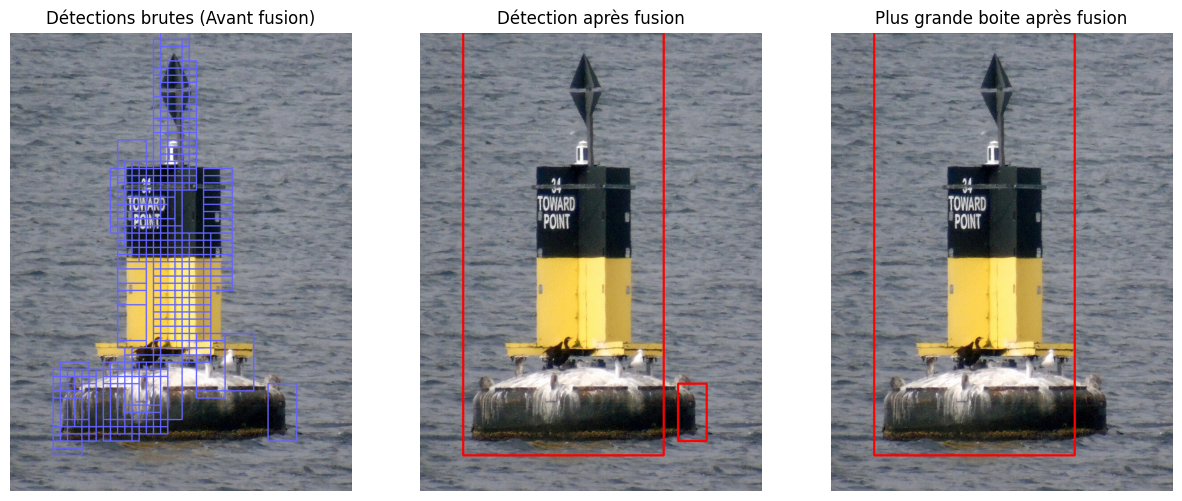

In [8]:
# On applique la détection sur une image test
chemin_image_test = adresse_img
img_test = cv2.imread(chemin_image_test)

img_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
img_draw_raw = img_rgb.copy() # Pour afficher toutes les détections
img_draw_raw_fus = img_rgb.copy() # Pour afficher toutes les détections fusionnées
img_draw_raw_fus_fin = img_rgb.copy() # Pour afficher la plus grande boîte finale

# Variables pour le parcours
step_size = 16  # La fenêtre avance de 16 pixels à chaque fois
detections = [] # Stockera les [xmin, ymin, xmax, ymax]

# Fonction pour faire glisser une fenêtre sur l'image et renvoyer ses coordonnées
def sliding_window(image, step_size, window_size):
    """Fait glisser une fenêtre sur l'image et renvoie ses coordonnées."""
    for y in range(0, image.shape[0] - window_size[1], step_size):
        for x in range(0, image.shape[1] - window_size[0], step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])
            
# Parcours de l'image
for (x, y, window) in sliding_window(img_rgb, step_size, winSize):
    if window.shape[0] != winSize[1] or window.shape[1] != winSize[0]:
        continue
        
    # On extrait les features HOG de la petite fenêtre
    features = extract_hog_features(window)
    
    # Le modèle SVM prédit si c'est une bouée (1) ou non (0)
    prediction = svm_model.predict([features])[0]
    
    if prediction == 1:
        # On sauvegarde les coordonnées si une bouée est détectée
        detections.append([x, y, x + winSize[0], y + winSize[1]])
        # On dessine un rectangle fin bleu clair pour montrer le bruit des détections brutes
        cv2.rectangle(img_draw_raw, (x, y), (x + winSize[0], y + winSize[1]), (100, 100, 255), 2)

print(f"Trouvé {len(detections)} fenêtres candidates.")

# On fusionne les boîtes englobantes qui se chevauchent pour réduire le nombre de détections brutes
boites_raw = fusionner_boites_englobantes(detections)

# Dessin de la/les boîte(s) finale(s) en rouge épais
for (startX, startY, endX, endY) in boites_raw:
    cv2.rectangle(img_draw_raw_fus, (startX, startY), (endX, endY), (255, 0, 0), 4)

# On fusionne les boîtes englobantes qui se chevauchent pour réduire le nombre de détections brutes
boite_grande = garder_plus_grande_boite(boites_raw)

# Dessin de la/les boîte(s) finale(s) en rouge épais
cv2.rectangle(img_draw_raw_fus_fin, (boite_grande[0], boite_grande[1]), (boite_grande[2], boite_grande[3]), (255, 0, 0), 4)

# Affichage des résultats
plt.figure(figsize=(15, 6))

plt.subplot(131)
plt.imshow(img_draw_raw)
plt.title("Détections brutes (Avant fusion)")
plt.axis("off")

plt.subplot(132)
plt.imshow(img_draw_raw_fus)
plt.title("Détection après fusion")
plt.axis("off")

plt.subplot(133)
plt.imshow(img_draw_raw_fus_fin)
plt.title("Plus grande boite après fusion")
plt.axis("off")

plt.show()

### Statistiques de la détection

On calcule dans cette partie les métriques liées à la détection c'est-à-dire la moyenne des IoU de chaque image où l'IoU est définie par 
$$ IoU = \frac{\text{Intersection des aires des bounding boxes}}{\text{Union des aires des bounding boxes}} $$

Au lieu de calculer le mAP (mean Average Precision), nous calculons le mAP @ 50 que l'on va définir de façon plus facile par : $$ \text{mAP @ 0.50} = \frac{1}{N} \sum_{i = 1}^{N} \mathbb{1}_{\text{IoU}_i > 0.5} $$ 

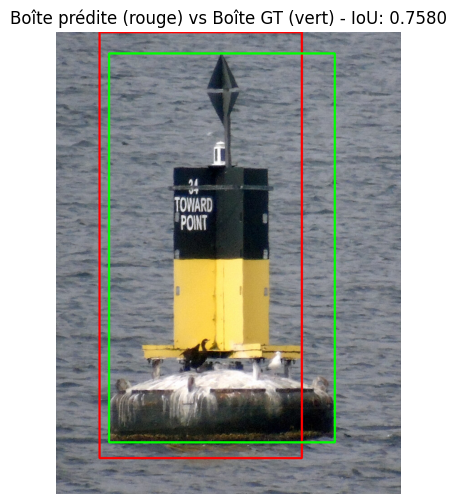

In [9]:
# Calcul de l'IoU entre la boîte prédite et la boîte GT
iou = calculate_iou(boite_grande, liste[1:])
img_draw = img_rgb.copy()

cv2.rectangle(img_draw, (boite_grande[0], boite_grande[1]), (boite_grande[2], boite_grande[3]), (255, 0, 0), 4) # Boîte prédite en rouge
cv2.rectangle(img_draw, (liste[1], liste[2]), (liste[3], liste[4]), (0, 255, 0), 4) # Boîte GT en vert
plt.figure(figsize=(8, 6))
plt.imshow(img_draw)
plt.title(f"Boîte prédite (rouge) vs Boîte GT (vert) - IoU: {iou:.4f}")
plt.axis("off")
plt.show()

In [10]:
# Définition du set de test (images non utilisées pour l'entraînement)
chemins_test = im_add[num_samples:]
labels_test = labels[num_samples:]

ious = []

print(f"Évaluation sur {len(chemins_test)} images de test...")

for idx in range(len(chemins_test)):
    img = cv2.imread(chemins_test[idx])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for sliding window

    # Ground Truth
    gt_box = labels_test[idx][1:] # [xmin, ymin, xmax, ymax]

    # Détection
    detections = []
    for (x, y, window) in sliding_window(img_rgb, step_size, winSize):
        if window.shape[0] != winSize[1] or window.shape[1] != winSize[0]:
            continue

        features = extract_hog_features(window)
        prediction = svm_model.predict([features])[0]

        if prediction == 1:
            detections.append([x, y, x + winSize[0], y + winSize[1]])

    if detections:
        boites_raw = fusionner_boites_englobantes(detections)
        pred_box = garder_plus_grande_boite(boites_raw)
        if pred_box:
            iou = calculate_iou(gt_box, pred_box)
        else:
            iou = 0.0 # No valid bounding box found after merging/filtering
    else:
        iou = 0.0 # No detections at all

    ious.append(iou)

# Calcul des métriques
mean_iou = np.mean(ious)
map50 = np.mean([1 if i > 0.5 else 0 for i in ious])

print(f"\n--- Résultats de Détection ---")
print(f"Mean IoU : {mean_iou:.4f}")
print(f"mAP @ 50 : {map50:.4f}")

Évaluation sur 84 images de test...

--- Résultats de Détection ---
Mean IoU : 0.5409
mAP @ 50 : 0.7024


Malgré le temps d'exécution pour les images de test (5min), le résultat est satisfaisant avec une moyenne d'IoU de 54%. 

### Classification : Pas à pas

Pour la classification, nous partons de l'image déjà rognée grâce aux bounding boxes déjà annotées dans le dataset pour nous concentrer sur la tâche de classification.

La méthode "Machine Learning" que nous allons appliquer dans cette partie a été vu dans le module "Image Description" et "Advanced Image Analysis" du bloc "Image Science (1)". 

Nous allons nous utiliser une approche d'extraction de couleurs pour avoir un masque binaire des éléments noirs et jaune de l'image. Ensuite, nous les nettoierons en appliquant un masque pour enlever les éléments haut et bas de l'image pouvant parasiter les mesures et en faisant des opérations morphologiques. Puis, nous appliquerons l'algorithme des K-Means pour déterminer des clusters qui rassemblent des groupes de pixels sombres et d'autres clusters groupant les pixels jaunes. Enfin, nous lirons ces clusters dans l'ordre de haut en bas pour trouver l'ordre de l'enchaînement des couleurs et affecter à cet ordre un cardinal.

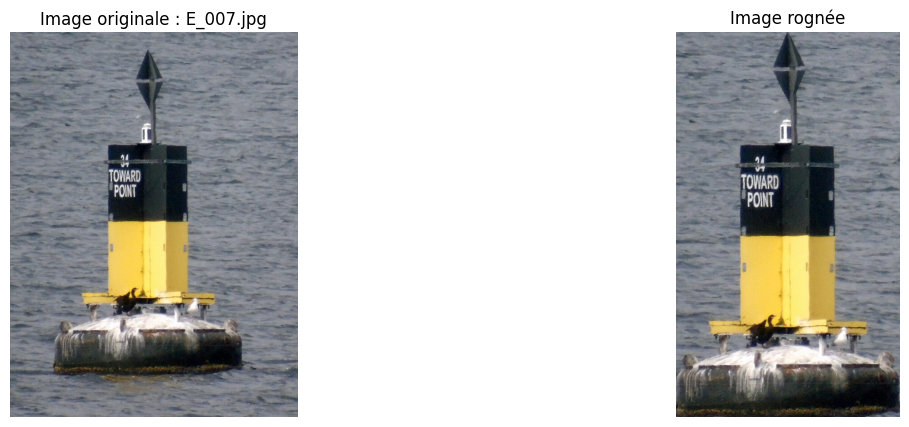

In [13]:
# Affectation de l'image originale et l'image rognée
img_orig = np.double(plt.imread(adresse_img));
img_orig /= img_orig.max()
img_c = img_orig[liste[2]:liste[4], liste[1]:liste[3]]

# Affichage des images
plt.figure(figsize=(15,5))
plt.subplot(121); plt.title(f"Image originale : {adresse_img[28:]}"); plt.imshow(img_orig); plt.axis("off");
plt.subplot(122); plt.imshow(img_c); plt.title(f"Image rognée"); plt.axis("off");

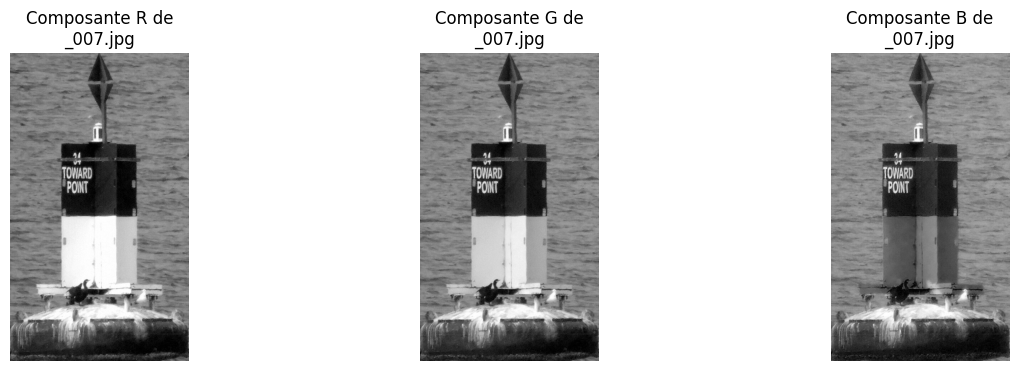

In [14]:
# Affichage des 3 composantes couleurs de l'image rognée
R, G, B = img_c[:,:,0], img_c[:,:,1], img_c[:,:,2]

# Affichage des images
plt.figure(figsize=(15,4))
plt.subplot(131); plt.imshow(R, cmap = "gray"); plt.title(f"Composante R de\n{adresse_img[29:]}"); plt.axis("off");
plt.subplot(132); plt.imshow(G, cmap = "gray"); plt.title(f"Composante G de\n{adresse_img[29:]}"); plt.axis("off");
plt.subplot(133); plt.imshow(B, cmap = "gray"); plt.title(f"Composante B de\n{adresse_img[29:]}"); plt.axis("off");

In [15]:
# Initialisation de la taille de l'image
H, W, C = len(img_c[:,0,0]), len(img_c[0,:,:]), len(img_c[0,0,:])
print(f"Hauteur : {H}, Largeur : {W}, Canal : {C}")

Hauteur : 862, Largeur : 500, Canal : 3


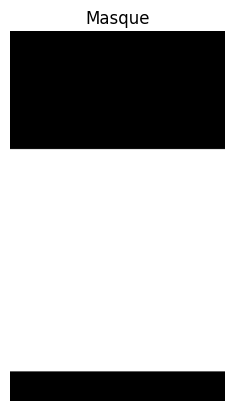

In [16]:
# On crée un masque pour enlever le haut de l'image pour retirer le noir du cône et le bas de l'image pour retirer des potentiels éléments parasites
mask_cone = np.zeros((H, W))
seuil_sup = int(0.32*H);
seuil_inf = int(0.92*H);
mask_cone[seuil_sup:seuil_inf,:] = 1;

# Affichage du masque
plt.imshow(mask_cone, cmap = "gray"); plt.title("Masque");  plt.axis("off");

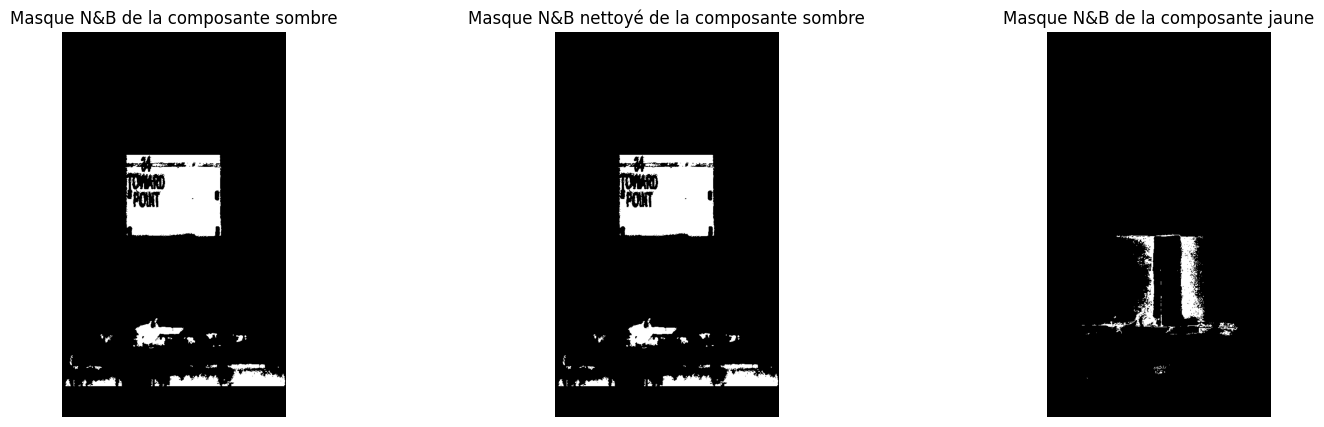

In [17]:
# Création manuelle des masques pour les composantes de l'image
BW_black = ((R < 0.3) & (G < 0.5) & (B < 0.3)) * mask_cone
BW_yellow = ((R > 0.4) & (G > 0.3) & (B < 0.3)) * mask_cone

# Application du nettoyage sur le masque noir
BW_black_cleaned = clean_noise(BW_black, threshold=1) # pour c = 21 erreur si threshold > 9

# Affichage des images
plt.figure(figsize=(18,5))
plt.subplot(131); plt.imshow(BW_black, vmin = 0, vmax =1, cmap = 'gray'); plt.title("Masque N&B de la composante sombre"); plt.axis("off");
plt.subplot(132); plt.imshow(BW_black_cleaned, vmin = 0, vmax =1, cmap = 'gray'); plt.title("Masque N&B nettoyé de la composante sombre"); plt.axis("off");
plt.subplot(133); plt.imshow(BW_yellow, cmap='gray'); plt.title("Masque N&B de la composante jaune"); plt.axis("off");


On effectue l'algo de Kmeans

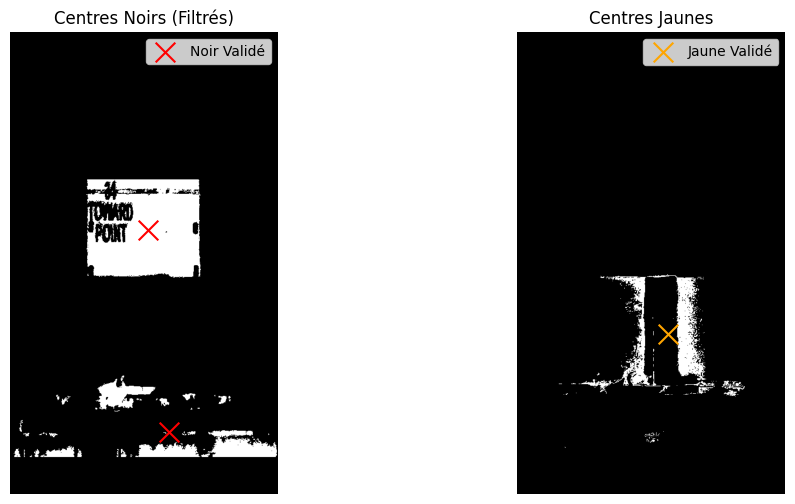

In [18]:
# Extraction des centres initiaux
h, w = BW_black_cleaned.shape
centers_black = get_clusters(BW_black_cleaned, h, w)
centers_yellow = get_clusters(BW_yellow, h, w)

# Logique de suppression (Noir trop proche du Jaune) avec un seuil de proximité de 5% de la hauteur de l'image
seuil_proximite = 0.05 * h
filtered_black = []
for cb in centers_black:
    trop_proche = False
    for cy in centers_yellow:
        dist = np.linalg.norm(cb - cy)
        if dist < seuil_proximite:
            trop_proche = True
            print(f"Cluster noir supprimé : trop proche d'un cluster jaune (dist: {dist:.2f}px)")
            break
    if not trop_proche:
        filtered_black.append(cb)
centers_black_final = np.array(filtered_black)

# Affichage des images
plt.figure(figsize=(12, 6))
# Masque Noir
plt.subplot(121); plt.imshow(BW_black, cmap='gray'); plt.title("Centres Noirs (Filtrés)");  plt.axis("off");
if len(centers_black_final) > 0:
    plt.scatter(centers_black_final[:, 1], centers_black_final[:, 0], c='red', marker='x', s=200, label='Noir Validé')
    plt.legend();
# Masque Jaune
plt.subplot(122); plt.imshow(BW_yellow, cmap='gray'); plt.title("Centres Jaunes"); plt.axis("off");
if len(centers_yellow) > 0:
    plt.scatter(centers_yellow[:, 1], centers_yellow[:, 0], c='orange', marker='x', s=200, label='Jaune Validé')
    plt.legend()

In [19]:
# On initialise les variables pour obtenir la séquence de couleurs
L0, L1, L2 = [], centers_black_final[:,0], centers_yellow[:,0]
n1, n2 = len(L1), len(L2)
i, j = 0, 0

while i < len(L1) and j < len(L2):
    if L1[i] < L2[j]:
        L0.append("NOIR")
        i += 1
    elif L1[i] > L2[j]:
        L0.append("JAUNE")
        j += 1
while i < len(L1):
    L0.append("NOIR")
    i += 1
while j < len(L2):
    L0.append("JAUNE")
    j += 1

# On enlève les doublons (série "noir", "noir" en "noir" par exemple)
L0f = [L0[0]]
for k in range(1,n1+n2):
    if L0[k] != L0[k-1] : L0f.append(L0[k])

# Habituellement, il y a des résidus noirs en bas des bouées, s'il y a 4 éléments dans L0f, on enlève le dernier :
L0f = L0f[:3]

# On veut le cardinal représentant
if L0f == ['NOIR', 'JAUNE']: resultat = "NORD"
elif L0f == ['JAUNE', 'NOIR']: resultat = "SUD"
elif L0f == ['NOIR', 'JAUNE', 'NOIR']: resultat = "EST"
elif L0f == ['JAUNE', 'NOIR', 'JAUNE']: resultat = "OUEST"
else: resultat = "Inconnu"

print(f"Séquence intermédiaire : {L0}")
print(f"Séquence finale : {L0f}")
print(f"Classification finale : {resultat}")

Séquence intermédiaire : ['NOIR', 'JAUNE', 'NOIR']
Séquence finale : ['NOIR', 'JAUNE', 'NOIR']
Classification finale : EST


Rappel des codes couleurs des cardinaux :
NORD : ['NOIR', 'JAUNE'], SUD : ['JAUNE', 'NOIR'], EST : ['NOIR', 'JAUNE', 'NOIR'], OUEST : ['JAUNE', 'NOIR', 'JAUNE']

C'est le bon résultat car on a prédit EST et c'était bien EST


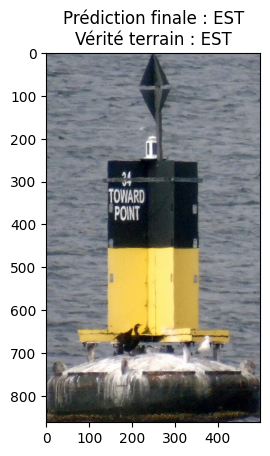

In [20]:
print("Rappel des codes couleurs des cardinaux :")
print(f"NORD : ['NOIR', 'JAUNE'], SUD : ['JAUNE', 'NOIR'], EST : ['NOIR', 'JAUNE', 'NOIR'], OUEST : ['JAUNE', 'NOIR', 'JAUNE']\n")

plt.imshow(img_c);
plt.title(f"Prédiction finale : {resultat}\nVérité terrain : {dict_card_fr[liste[0]]}");

if dict_card_fr[liste[0]] == resultat :
    print(f"C'est le bon résultat car on a prédit {resultat} et c'était bien {dict_card_fr[liste[0]]}")
else :
    print(f"Ce n'est pas le bon résultat car on a prédit {resultat} au lieu de {dict_card_fr[liste[0]]}")

### Statistiques de la classification

On calcule dans cette partie les métriques usuelles liées à la classification définies par :
$$ \text{Precision} = \frac{\text{TP}}{\text{TP}+\text{FP}} $$
$$ \text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}} $$
$$ \text{F1-Score} = \frac{2}{\frac{1}{\text{Precision}}+\frac{1}{\text{Recall}}} $$
$$ \text{Accuracy} = \frac{\text{TP}+\text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}} $$


Fonctions à exécuter pour utiliser le programme pour calculer les statistiques (ce sont les mêmes que pour la section "pas à pas", on effectue les mêmes opérations mais sur toutes les images).

In [ ]:
BONS, MAUVAIS = [], []
dico_stats = {f"{gt}_{pred}": 0 for pred in ["EST", "NORD", "SUD", "OUEST"] for gt in ["EST", "NORD", "SUD", "OUEST"]}

# Initialisation des listes
im_add, labels = init_lists_0()

# On créera une liste de cardinaux à partir des véritables étiquettes (GT_card) pour faciliter la lecture des résultats
dict_card_fr = {0: "EST", 1: "NORD", 2: "SUD", 3: "OUEST"} 
GT_card = [dict_card_fr[labels[k][0]] for k in range(len(im_add))]

for c in range(len(im_add)):
    # Choix d'une image
    adresse_img, liste = im_add[c], labels[c]

    # Création de l'image originale et l'image rognée
    img_orig = np.double(plt.imread(adresse_img));
    img_orig /= img_orig.max()
    img_c = img_orig[liste[2]:liste[4], liste[1]:liste[3]]

    # Initialisation des 3 composantes couleurs de l'image rognée
    R, G, B = img_c[:,:,0], img_c[:,:,1], img_c[:,:,2]

    # Initialisation de la taille de l'image
    H, W, C = len(img_c[:,0,0]), len(img_c[0,:,:]), len(img_c[0,0,:])

    # On crée un masque pour enlever le haut de l'image pour retirer le noir du cône
    mask_cone = np.zeros((H, W))
    seuil_sup = int(0.32*H);
    seuil_inf = int(0.92*H);
    mask_cone[seuil_sup:seuil_inf,:] = 1;

    # Création manuelle des masques
    BW_black = ((R < 0.3) & (G < 0.5) & (B < 0.3)) * mask_cone
    BW_yellow = ((R > 0.4) & (G > 0.3) & (B < 0.3)) * mask_cone

    # Application du nettoyage
    BW_black_cleaned = clean_noise(BW_black, threshold=1)

    # --- 1. Extraction des centres initiaux ---
    h, w = BW_black_cleaned.shape
    centers_black = get_clusters(BW_black_cleaned, h, w)
    centers_yellow = get_clusters(BW_yellow, h, w)

    # --- 2. Logique de suppression (Noir trop proche du Jaune) ---
    # Seuil de proximité : 5% de la hauteur de l'image
    seuil_proximite = 0.05 * h
    filtered_black = []

    for cb in centers_black:
        trop_proche = False
        for cy in centers_yellow:
            # Calcul de la distance euclidienne entre le centre noir et le centre jaune
            dist = np.linalg.norm(cb - cy)
            if dist < seuil_proximite:
                trop_proche = True
                break
        if not trop_proche:
            filtered_black.append(cb)

    centers_black_final = np.array(filtered_black)

    # On initialise les variables pour obtenir la séquence de couleurs
    L0, L1, L2 = [], centers_black_final[:,0], centers_yellow[:,0]
    n1, n2 = len(L1), len(L2)
    i, j = 0, 0

    while i < len(L1) and j < len(L2):
        if L1[i] < L2[j]:
            L0.append("NOIR")
            i += 1
        elif L1[i] > L2[j]:
            L0.append("JAUNE")
            j += 1
    while i < len(L1):
        L0.append("NOIR")
        i += 1
    while j < len(L2):
        L0.append("JAUNE")
        j += 1

    # On enlève les doublons (série "noir", "noir" en "noir" par exemple)
    L0f = [L0[0]]

    for k in range(1,n1+n2):
        if L0[k] != L0[k-1] : L0f.append(L0[k])

    # Habituellement, il y a des résidus noirs en bas des bouées, s'il y a 4 éléments dans L0f, on enlève le dernier :
    L0f = L0f[:3]

    # On veut le cardinal représentant
    if L0f == ['NOIR', 'JAUNE']: resultat = "NORD"
    elif L0f == ['JAUNE', 'NOIR']: resultat = "SUD"
    elif L0f == ['NOIR', 'JAUNE', 'NOIR']: resultat = "EST"
    elif L0f == ['JAUNE', 'NOIR', 'JAUNE']: resultat = "OUEST"
    else: resultat = "Inconnu"


    if GT_card[c] == resultat :
        BONS.append(c)
    else :
        MAUVAIS.append(c)

    # Dictionnaire de statistiques où les clés sont de type "VéritéTerrain_Prediction" pour créer un tableau avec Accuracy, Precision, Recall, and F1-score.
    dico_stats[f"{GT_card[c]}_{resultat}"] += 1

metriques = calculer_metriques_classif(dico_stats)
afficher_metriques_classif(metriques)

# Affichage des détails des statistiques ou non
STATS = False
if STATS :
    print("Les bonnes balises sont : ", BONS)
    print("Les mauvaises balises sont : ", MAUVAIS)
    print("\nDictionnaire de statistiques : ", dico_stats)

--- MÉTROLOGIE GLOBALE ---
Accuracy globale: 73.05%

--- MÉTROLOGIE PAR CLASSE ---
Classe SUD :
  Précision : 91.67%
  Rappel    : 59.46%
  F1-score  : 72.13%
  Accuracy  : 89.82%
  (Détails  : TP=22, FP=2, FN=15)

Classe OUEST :
  Précision : 55.32%
  Rappel    : 76.47%
  F1-score  : 64.20%
  Accuracy  : 82.63%
  (Détails  : TP=26, FP=21, FN=8)

Classe EST :
  Précision : 61.11%
  Rappel    : 89.19%
  F1-score  : 72.53%
  Accuracy  : 85.03%
  (Détails  : TP=33, FP=21, FN=4)

Classe NORD :
  Précision : 97.62%
  Rappel    : 69.49%
  F1-score  : 81.19%
  Accuracy  : 88.62%
  (Détails  : TP=41, FP=1, FN=18)



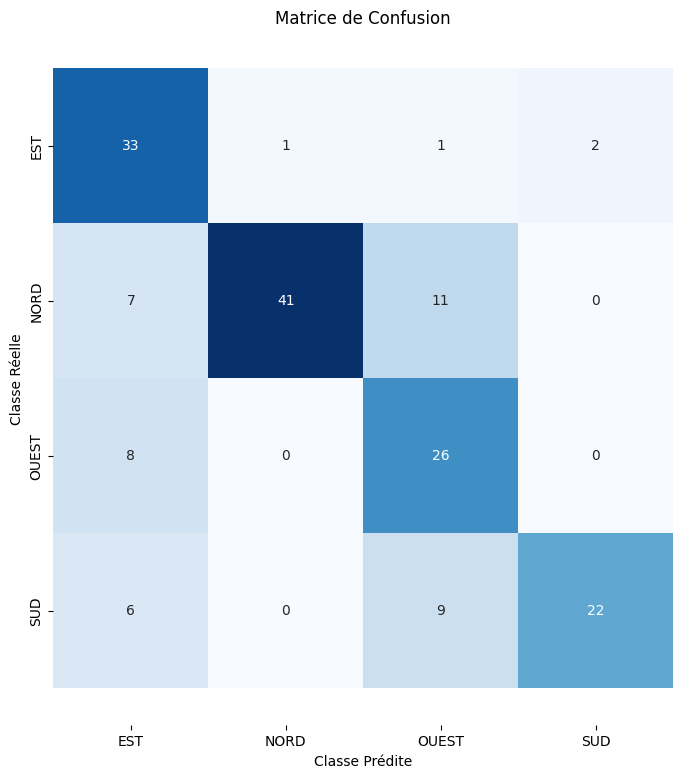

In [24]:
# Extraction des classes uniques à partir des clés du dictionnaire de statistiques
classes = sorted(list(set(k.split('_')[0] for k in dico_stats.keys()) | set(k.split('_')[1] for k in dico_stats.keys())))

# Préparation des listes pour les étiquettes réelles et prédites
y_true = []
y_pred = []

for key, count in dico_stats.items():
    gt, pred = key.split('_')
    y_true.extend([gt] * count)
    y_pred.extend([pred] * count)

# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Conversion en DataFrame pour une meilleure visualisation avec seaborn
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

# Affichage de la matrice de confusion
plt.figure(figsize=(8, 9))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de Confusion')
plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.axis('equal')
plt.show()

Les résultats sont globalement satisfaisants pour une maison "faite à la main" : 3/4 des bouées ont bien été classés. 

NB : Le score était plus haut avant l'extension du dataset pendant les vacances.